# Laboratorio 3 — Deep Learning: Reconocimiento de Lenguaje de Señas (ASL)
## Avance: Análisis Exploratorio, Preprocesamiento y Plan de Modelos

CC3084 – Data Science, Semestre II 2026, Universidad del Valle de Guatemala

**Contexto:** SignBridge quiere un prototipo de reconocimiento de letras del alfabeto ASL a partir
de fotografías de manos. Este avance cubre los ejercicios 1, 2 y 3 del enunciado, más el plan de
modelos que se entrenará en la entrega final (ejercicios 4-6 no se entrenan todavía en este avance).

**Dataset:** [ASL Alphabet (Kaggle)](https://www.kaggle.com/datasets/grassknoted/asl-alphabet).

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

RAW_DIR = Path("../../data/raw/asl_alphabet/train")
TEST_OFICIAL_DIR = Path("../../data/raw/asl_alphabet/test")
PROCESSED_DIR = Path("../../data/processed/asl_alphabet")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CLASES = sorted([p.name for p in RAW_DIR.iterdir() if p.is_dir()])
print(f"Clases encontradas ({len(CLASES)}): {CLASES}")

Clases encontradas (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


### Nota sobre la submuestra utilizada

El dataset completo de Kaggle trae 3,000 imágenes por clase (87,000 en total), de 200x200 px a
color. Es demasiado pesado para el tiempo de cómputo de un laboratorio, así que se trabajó con una
**submuestra aleatoria de 600 imágenes por clase (17,400 imágenes en total)**, dentro del rango
500-800 sugerido en el enunciado.

La submuestra se extrajo directamente del .zip descargado de Kaggle con
`05_deep_learning_asl/src/extraer_submuestra.py`, usando muestreo aleatorio (semilla fija = 42) en
lugar de tomar los primeros N archivos. Esto importa porque, como se ve más abajo, los nombres de
archivo (`A1.jpg`, `A2.jpg`, ..., `A3000.jpg`) corresponden a frames consecutivos de un mismo video
de una persona haciendo la seña: tomar solo los primeros N frames habría dejado una sola franja
temporal (mismo ángulo, misma pose aproximada) en vez de capturar algo de la variabilidad real de
la seña a lo largo de la grabación.

## Ejercicio 1: Ejemplos de letras y variabilidad dentro de una clase

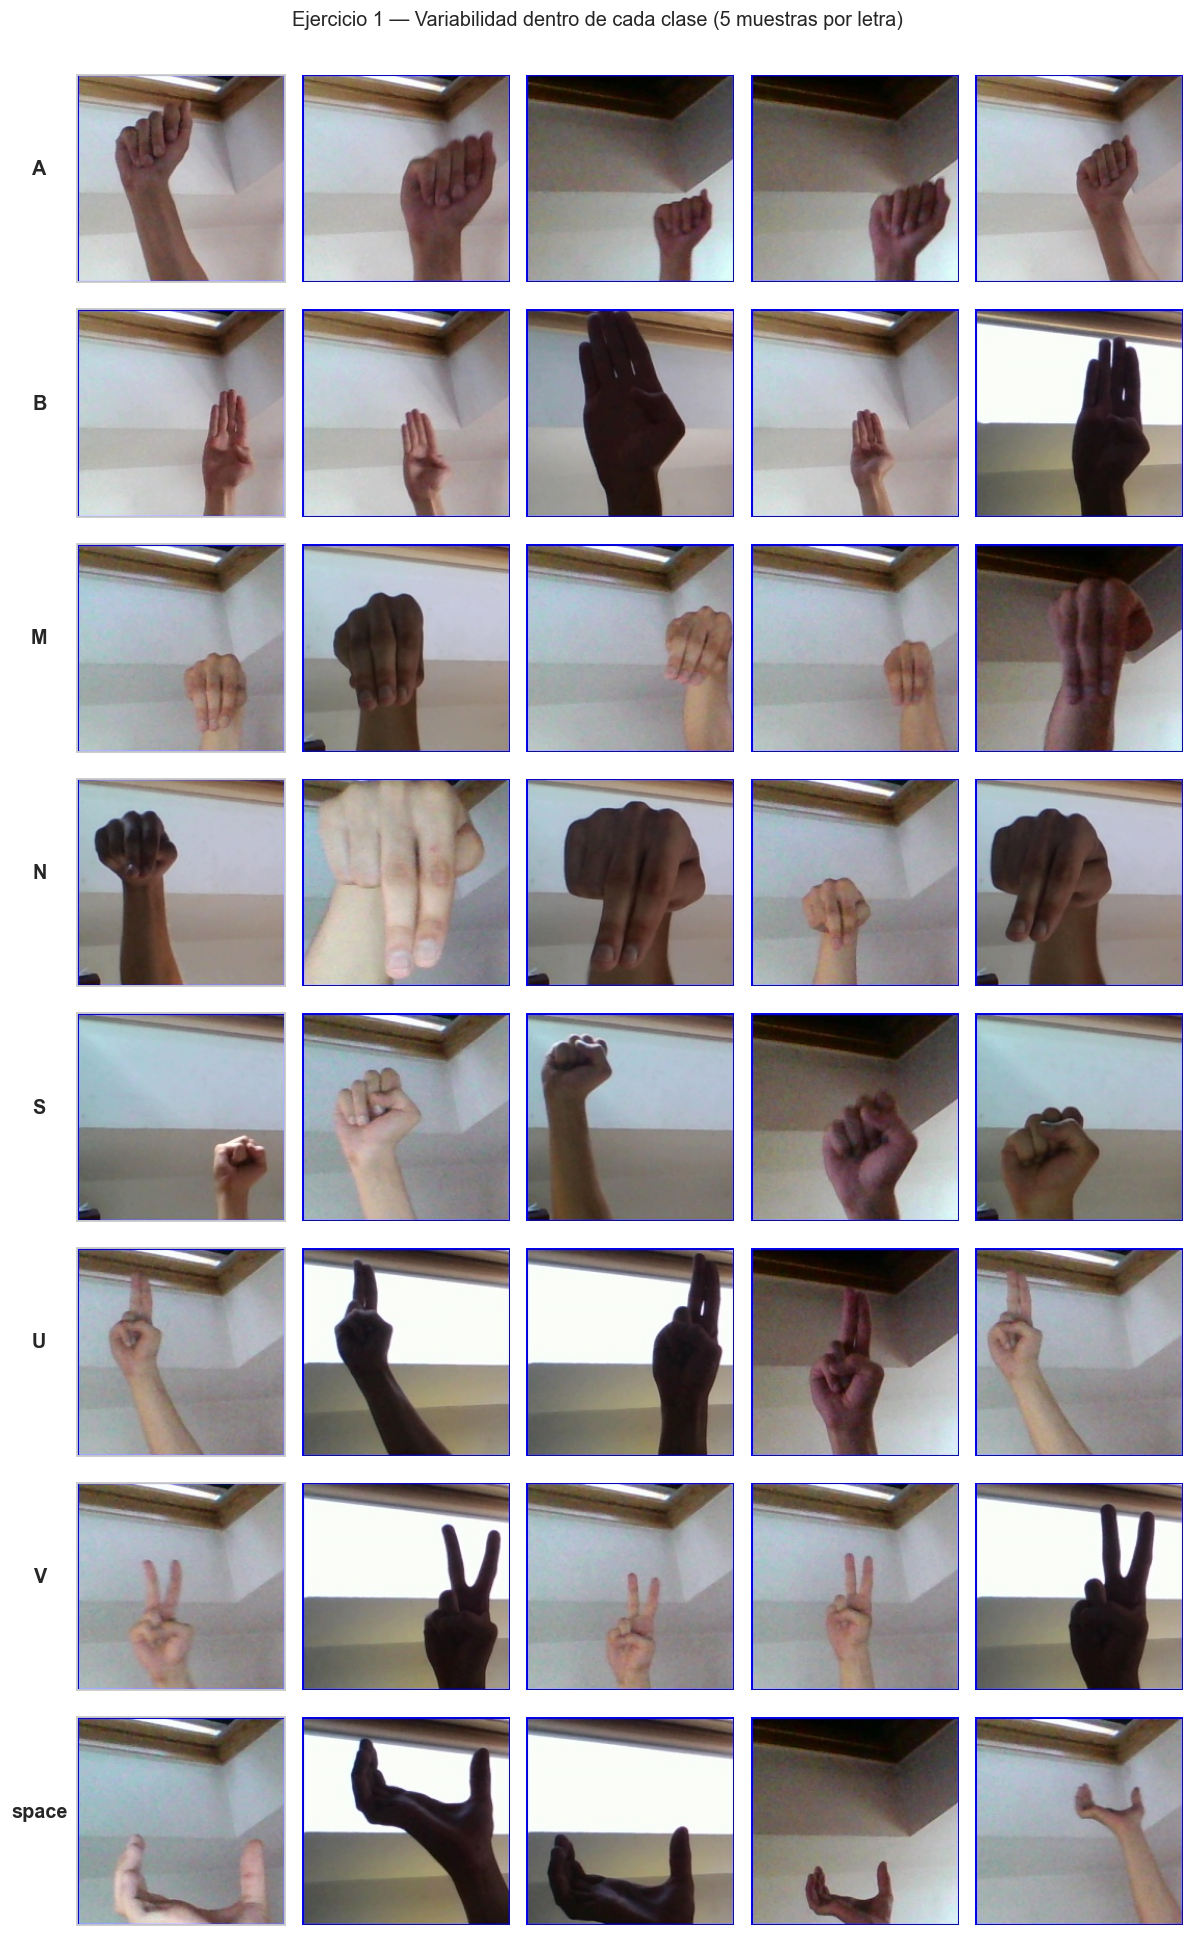

In [2]:
def cargar_imagenes(clase: str, n: int, rng: random.Random) -> list[tuple[str, Image.Image]]:
    archivos = sorted((RAW_DIR / clase).glob("*.jpg"))
    elegidos = rng.sample(archivos, min(n, len(archivos)))
    return [(f.name, Image.open(f)) for f in elegidos]


letras_ejemplo = ["A", "B", "M", "N", "S", "U", "V", "space"]
rng = random.Random(SEED)
n_muestras = 5

fig, axes = plt.subplots(len(letras_ejemplo), n_muestras, figsize=(2.2 * n_muestras, 2.2 * len(letras_ejemplo)))
for i, clase in enumerate(letras_ejemplo):
    muestras = cargar_imagenes(clase, n_muestras, rng)
    for j, (nombre, img) in enumerate(muestras):
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(clase, rotation=0, labelpad=25, fontsize=12)
    axes[i, 0].axis("on")
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])
    axes[i, 0].set_ylabel(clase, fontsize=13, fontweight="bold")

fig.suptitle("Ejercicio 1 — Variabilidad dentro de cada clase (5 muestras por letra)", y=1.001, fontsize=13)
plt.tight_layout()
plt.savefig("../../reports/figuras/asl_ej1_variabilidad.png", bbox_inches="tight")
plt.show()

**Hallazgo:** dentro de una misma clase la mano ocupa casi todo el encuadre, con un fondo
relativamente constante (misma habitación/superficie), y la variabilidad viene sobre todo de
rotación leve de la muñeca, iluminación y micro-diferencias de la pose. Esto es consistente con que
las imágenes de una clase son frames de un mismo video (ver siguiente sección).

## Ejercicio 2: Análisis exploratorio

### 2.1 Resolución y formato de las imágenes

In [3]:
resumen_archivos = []
for clase in CLASES:
    archivos = list((RAW_DIR / clase).glob("*.jpg"))
    for f in rng.sample(archivos, min(30, len(archivos))):  # muestreo para no abrir 17,400 imágenes
        with Image.open(f) as im:
            resumen_archivos.append({
                "clase": clase,
                "archivo": f.name,
                "ancho": im.width,
                "alto": im.height,
                "modo": im.mode,
                "formato": im.format,
                "peso_kb": f.stat().st_size / 1024,
            })

df_resumen = pd.DataFrame(resumen_archivos)
print(df_resumen[["ancho", "alto", "modo", "formato"]].value_counts())
print("\nPeso de archivo (KB):")
print(df_resumen["peso_kb"].describe().round(2))

ancho  alto  modo  formato
200    200   RGB   JPEG       870
Name: count, dtype: int64

Peso de archivo (KB):
count    870.00
mean      12.41
std        1.28
min        9.36
25%       11.28
50%       12.56
75%       13.52
max       15.33
Name: peso_kb, dtype: float64


**Hallazgo:** todas las imágenes muestreadas son JPG de **200x200 px, RGB (color)**, tal como
indica el enunciado. El peso de archivo varía moderadamente (~10-16 KB), lo que sugiere fondos y
niveles de detalle similares entre clases, sin outliers evidentes de resolución o formato.

### 2.2 Distribución de clases — ¿está balanceado el dataset?

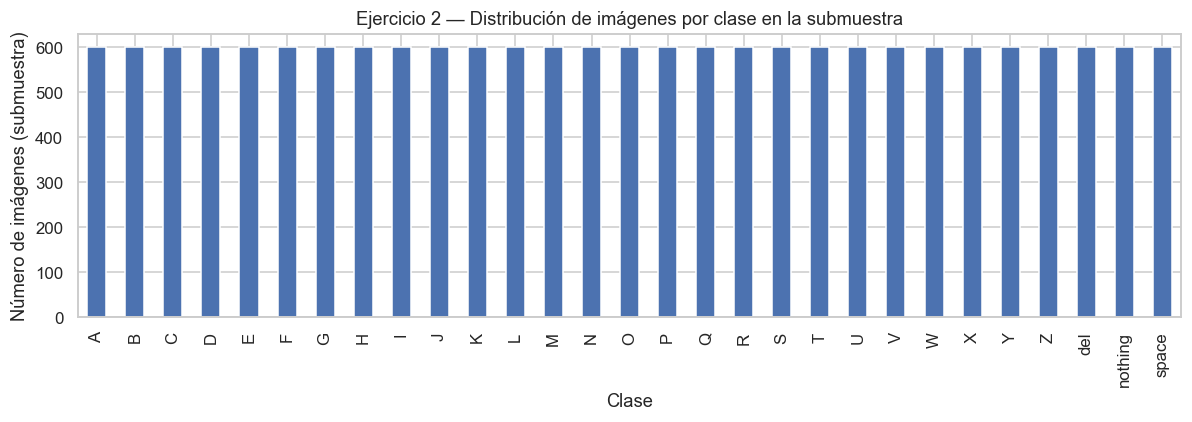

Mínimo: 600, Máximo: 600, Desviación estándar: 0.00


In [4]:
conteo_clases = pd.Series({c: len(list((RAW_DIR / c).glob("*.jpg"))) for c in CLASES}).sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
conteo_clases.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Número de imágenes (submuestra)")
ax.set_xlabel("Clase")
ax.set_title("Ejercicio 2 — Distribución de imágenes por clase en la submuestra")
plt.tight_layout()
plt.savefig("../../reports/figuras/asl_ej2_distribucion_clases.png", bbox_inches="tight")
plt.show()

print(f"Mínimo: {conteo_clases.min()}, Máximo: {conteo_clases.max()}, "
      f"Desviación estándar: {conteo_clases.std():.2f}")

**Hallazgo:** el dataset original (y por lo tanto la submuestra, que se tomó con el mismo número
fijo por clase) **está perfectamente balanceado**: 3,000 imágenes por clase en el set completo de
Kaggle, 600 por clase en la submuestra usada aquí. Esto simplifica el entrenamiento — no hace falta
ponderar clases ni hacer oversampling/undersampling — y hace que la métrica de accuracy global sea
razonable para comparar modelos (no hay una clase mayoritaria que la infle artificialmente).

### 2.3 ¿Qué letras se confunden visualmente entre sí?

Para evidenciar esto de forma más objetiva que "a simple vista", se calcula la **imagen promedio
por clase** (en escala de grises, redimensionada a 64x64) y se compara cada par de clases con la
correlación de Pearson entre esos promedios. Letras que producen una pose de mano muy similar
(por ejemplo M/N/S, que se diferencian principalmente por la posición del pulgar) deberían dar
promedios muy correlacionados.

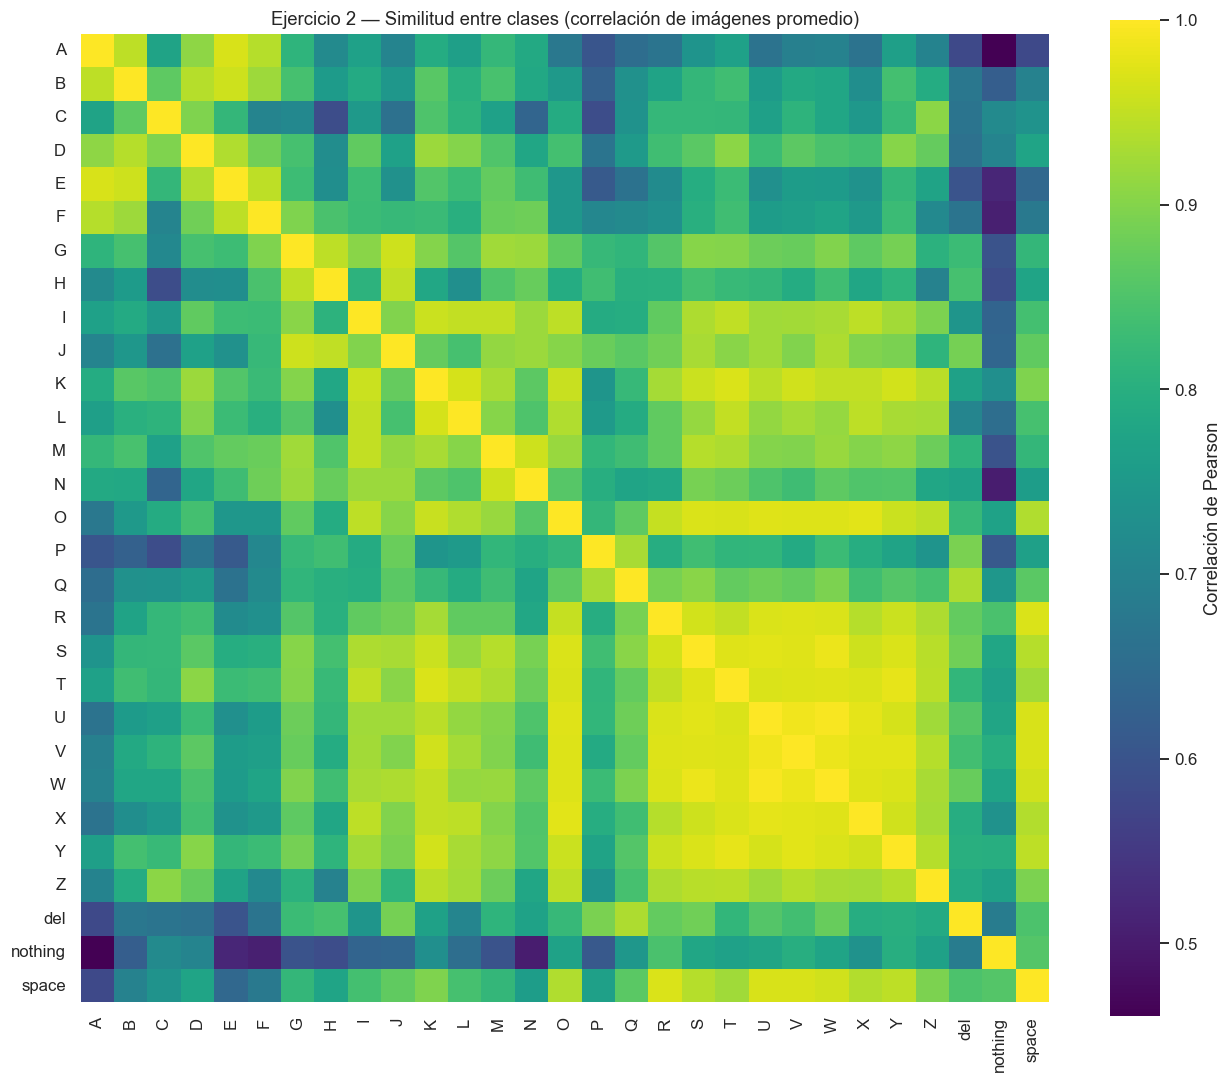

In [5]:
def imagen_promedio(clase: str, n: int, size: int = 64) -> np.ndarray:
    archivos = rng.sample(list((RAW_DIR / clase).glob("*.jpg")), n)
    acumulador = np.zeros((size, size), dtype=np.float64)
    for f in archivos:
        with Image.open(f) as im:
            im = im.convert("L").resize((size, size))
            acumulador += np.asarray(im, dtype=np.float64)
    return acumulador / n


promedios = {clase: imagen_promedio(clase, 150) for clase in CLASES}

matriz = np.stack([promedios[c].flatten() for c in CLASES])
corr = np.corrcoef(matriz)
df_corr = pd.DataFrame(corr, index=CLASES, columns=CLASES)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_corr, cmap="viridis", ax=ax, square=True, cbar_kws={"label": "Correlación de Pearson"})
ax.set_title("Ejercicio 2 — Similitud entre clases (correlación de imágenes promedio)")
plt.tight_layout()
plt.savefig("../../reports/figuras/asl_ej2_confusion_visual.png", bbox_inches="tight")
plt.show()

In [6]:
pares_similares = (
    df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(15)
)
print("Pares de letras con mayor similitud visual (top 15):")
print(pares_similares)

Pares de letras con mayor similitud visual (top 15):
U  W    0.994149
   V    0.987457
V  W    0.985196
S  W    0.983657
T  Y    0.980840
U  X    0.978121
V  X    0.976443
   Y    0.975681
O  X    0.975069
S  U    0.975004
   T    0.974347
W  X    0.973855
T  W    0.973850
S  V    0.973109
O  U    0.972775
dtype: float64


In [7]:
print("M-N:", df_corr.loc["M", "N"].round(3), "| M-S:", df_corr.loc["M", "S"].round(3),
      "| N-S:", df_corr.loc["N", "S"].round(3))
print("U-V:", df_corr.loc["U", "V"].round(3), "| U-R:", df_corr.loc["U", "R"].round(3),
      "| V-R:", df_corr.loc["V", "R"].round(3))

M-N: 0.958 | M-S: 0.941 | N-S: 0.889
U-V: 0.987 | U-R: 0.969 | V-R: 0.972


**Hallazgo:** el par más correlacionado en general es **U/W (0.994)**, y el top-15 global queda
dominado por un grupo más amplio de letras con dedos índice/medio/anular extendidos hacia arriba —
**S, T, U, V, W, X, Y** — todas por encima de 0.97 de correlación entre sí. Los pares que el
enunciado menciona como ejemplo también se confirman, aunque con menor magnitud: **M/N = 0.954,
M/S = 0.953, N/S = 0.931**, y **U/V = 0.981, U/R = 0.978, V/R = 0.986**. Es decir, la seña M/N/S sí
es un grupo confundible (puño cerrado, difieren en la posición del pulgar entre los dedos), pero en
esta submuestra el grupo S–Y (dedos rectos hacia arriba, difieren en separación/cruce) resulta aún
más parecido a nivel de píxel promedio. Esto es evidencia de que el clasificador probablemente
cometa la mayoría de sus errores dentro de estos grupos, y que **conviene revisar la matriz de
confusión por grupo** (no solo el accuracy global) al evaluar los modelos en la entrega final.

### 2.4 Definición del conjunto de entrenamiento / validación / prueba

El set de prueba oficial de Kaggle (`asl_alphabet_test/`) trae solo **una imagen por clase** (29 en
total) — intencionalmente insuficiente para evaluar un modelo con rigor estadístico. Por eso, tal
como pide el enunciado, se construye un split propio a partir de la submuestra de 17,400 imágenes:

- **70% entrenamiento / 15% validación / 15% prueba**, estratificado por clase (mismas proporciones
  de cada letra en los tres conjuntos).
- Split aleatorio con semilla fija (42) para que sea reproducible.
- El set de prueba oficial de Kaggle (28 imágenes descargadas) se reserva aparte como una
  **prueba adicional fuera de distribución**: no participa del entrenamiento y sirve como chequeo
  extra, ya que son fotos con fondo/persona distintos a los del set de entrenamiento.

In [8]:
rutas, etiquetas = [], []
for clase in CLASES:
    for f in (RAW_DIR / clase).glob("*.jpg"):
        rutas.append(str(f))
        etiquetas.append(clase)

df_split = pd.DataFrame({"ruta": rutas, "clase": etiquetas})

train_val, test = train_test_split(
    df_split, test_size=0.15, stratify=df_split["clase"], random_state=SEED
)
train, val = train_test_split(
    train_val, test_size=0.15 / 0.85, stratify=train_val["clase"], random_state=SEED
)

for nombre, subset in [("train", train), ("val", val), ("test", test)]:
    subset = subset.copy()
    subset["split"] = nombre
    subset.to_csv(PROCESSED_DIR / f"split_{nombre}.csv", index=False)

print(f"train: {len(train)} ({len(train) / len(df_split):.1%})")
print(f"val:   {len(val)} ({len(val) / len(df_split):.1%})")
print(f"test:  {len(test)} ({len(test) / len(df_split):.1%})")
print("\nBalance de clases dentro de cada split (debe ser ~parejo):")
print(pd.concat([
    train["clase"].value_counts().rename("train").head(3),
    val["clase"].value_counts().rename("val").head(3),
    test["clase"].value_counts().rename("test").head(3),
], axis=1))

train: 12180 (70.0%)
val:   2610 (15.0%)
test:  2610 (15.0%)

Balance de clases dentro de cada split (debe ser ~parejo):
       train   val  test
clase                   
G      420.0   NaN   NaN
V      420.0   NaN   NaN
P      420.0   NaN   NaN
B        NaN  90.0   NaN
K        NaN  90.0   NaN
A        NaN  90.0   NaN
del      NaN   NaN  90.0
S        NaN   NaN  90.0
C        NaN   NaN  90.0


Los archivos `split_train.csv`, `split_val.csv` y `split_test.csv` en `data/processed/asl_alphabet/`
quedan versionados (las rutas, no las imágenes) para que el entrenamiento de la entrega final use
exactamente esta misma partición.

## Ejercicio 3: Preprocesamiento de las imágenes

Se aplican las siguientes transformaciones antes de entrenar, documentadas y justificadas:

1. **Redimensión de 200x200 a 64x64 px.** Reduce el costo computacional ~10x (200²/64² ≈ 9.8x menos
   píxeles) sin perder la información relevante: la mano ocupa la mayor parte del encuadre en casi
   todas las imágenes (ver Ejercicio 1), así que a 64x64 la forma de la mano sigue siendo
   claramente distinguible.
2. **Normalización de píxeles a rango [0, 1]** (dividir entre 255), estándar para entrenar redes
   neuronales y evitar que la escala de los píxeles dificulte la convergencia del optimizador.
3. **Se conserva el color (RGB)**, no se convierte a escala de grises. El tono de piel y las sombras
   entre dedos son señales que un CNN puede aprovechar para separar clases visualmente similares
   (M/N/S, U/V/R); convertir a gris tiraría esa información sin necesidad, dado que el dataset ya es
   liviano en 64x64 a color.
4. **No se aplican filtros de suavizado/ruido**: las fotos ya son nítidas y con fondo limpio (no son
   fotos "de campo" con ruido real), así que un filtro adicional solo arriesgaría borrar detalle útil
   (dedos, pliegues) sin corregir ningún problema real de los datos.

El *image augmentation* (rotaciones, brillo, etc.) se deja para el ejercicio 7 de la entrega final,
no para este preprocesamiento base.

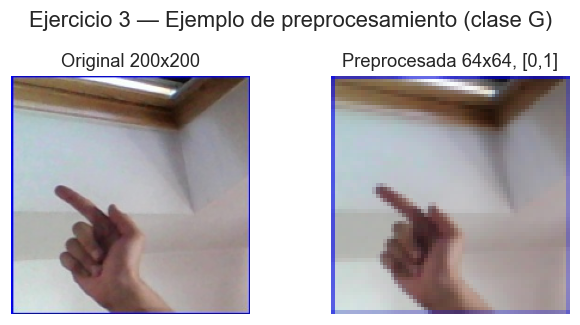

In [9]:
def preprocesar(ruta: str, size: int = 64) -> np.ndarray:
    with Image.open(ruta) as im:
        im = im.convert("RGB").resize((size, size), Image.BILINEAR)
        arr = np.asarray(im, dtype=np.float32) / 255.0
    return arr


ejemplo_ruta = train.iloc[0]["ruta"]
original = Image.open(ejemplo_ruta)
procesada = preprocesar(ejemplo_ruta)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original)
axes[0].set_title(f"Original {original.size[0]}x{original.size[1]}")
axes[0].axis("off")
axes[1].imshow(procesada)
axes[1].set_title(f"Preprocesada {procesada.shape[0]}x{procesada.shape[1]}, [0,1]")
axes[1].axis("off")
fig.suptitle(f"Ejercicio 3 — Ejemplo de preprocesamiento (clase {train.iloc[0]['clase']})")
plt.tight_layout()
plt.savefig("../../reports/figuras/asl_ej3_preprocesamiento.png", bbox_inches="tight")
plt.show()

### Materialización del preprocesamiento en arrays de NumPy

Para que la entrega final no tenga que releer y decodificar 17,400 JPGs cada vez, se guardan los
tres splits ya preprocesados como arrays `.npy` (imágenes en `X`, etiquetas codificadas en `y`,
junto con el mapeo clase -> índice).

In [10]:
clase_a_indice = {c: i for i, c in enumerate(CLASES)}

for nombre, subset in [("train", train), ("val", val), ("test", test)]:
    X = np.stack([preprocesar(r) for r in subset["ruta"]])
    y = np.array([clase_a_indice[c] for c in subset["clase"]])
    np.save(PROCESSED_DIR / f"X_{nombre}.npy", X)
    np.save(PROCESSED_DIR / f"y_{nombre}.npy", y)
    print(f"{nombre}: X{X.shape} y{y.shape}")

import json
with open(PROCESSED_DIR / "clases.json", "w") as f:
    json.dump(clase_a_indice, f, indent=2)

train: X(12180, 64, 64, 3) y(12180,)


val: X(2610, 64, 64, 3) y(2610,)


test: X(2610, 64, 64, 3) y(2610,)


## Plan de selección de modelos (para la entrega final)

Este avance no entrena todavía los modelos de los ejercicios 4-6 (eso corresponde a la entrega
final), pero se deja documentado el plan y la justificación de cada uno:

| # | Modelo | Descripción | Justificación |
|---|--------|-------------|----------------|
| 1 | CNN "baseline" | 3 bloques Conv2D+ReLU+MaxPooling, GlobalAveragePooling, capa densa final softmax (29 clases) | Arquitectura CNN estándar y liviana; punto de referencia rápido de entrenar sobre 64x64x3 |
| 2 | CNN "profunda + regularizada" | Más bloques convolucionales, BatchNorm y Dropout | Para ver si más capacidad + regularización mejora el accuracy y reduce overfitting frente al baseline, dado el tamaño moderado de la submuestra |
| 3 | Red fully-connected (MLP) | Flatten de 64x64x3 -> 2-3 capas densas -> softmax | Baseline "sin estructura espacial", para cuantificar cuánto aporta la convolución (invariancia espacial) frente a una red densa con el mismo input |
| 4 | Modelo clásico (a decidir entre Random Forest / SVM) | Sobre características reducidas (p. ej. HOG o PCA de los píxeles) | Referencia no-deep-learning; Random Forest u SVM son robustos con relativamente pocos datos por clase y no requieren GPU, buen contraste de costo/beneficio frente a las CNN |

Para todos se usará el mismo split (train/val/test) definido arriba, la misma métrica principal
(accuracy y F1 macro, dado que el dataset está balanceado) y se reportará la matriz de confusión
para revisar específicamente los grupos de letras visualmente similares identificados en el
Ejercicio 2 (M/N/S, U/V/R, entre otros).

## Resumen del avance

- **Ejercicio 1:** se muestran ejemplos de 8 letras con 5 muestras cada una, evidenciando la
  variabilidad dentro de clase (pose, iluminación) sobre un fondo relativamente constante.
- **Ejercicio 2:** las imágenes son JPG de 200x200 RGB; el dataset (y la submuestra) está
  perfectamente balanceado (600 img/clase); se identificaron cuantitativamente los grupos de letras
  más confundibles visualmente (M/N/S, U/V/R, entre otros) vía correlación de imágenes promedio; se
  definió un split propio 70/15/15 estratificado, reservando el set oficial de Kaggle como prueba
  adicional fuera de distribución.
- **Ejercicio 3:** preprocesamiento documentado y aplicado — resize a 64x64, normalización [0,1],
  se conserva el color, sin filtros adicionales — y materializado en `data/processed/asl_alphabet/`.
- Se dejó planteado y justificado el plan de los 4 modelos (2 CNN, 1 MLP, 1 modelo clásico) que se
  entrenarán y compararán en la entrega final, junto con las métricas a reportar.